
# Улучшение модели 3D CNN для сервиса детекции патологических образований в легких


## Этап 1. Импорт библиотек

In [1]:

import os
import glob
import random

import pandas as pd
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    fbeta_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


In [19]:
data_path = "/Users/aidungmas/Desktop/MFDP/Dataset"

annotations = pd.read_csv("annotations.csv")
candidates = pd.read_csv("candidates_V2.csv")
sample_submission = pd.read_csv("sampleSubmission.csv")

## Этап 2. Загрузка и анализ данных

В работе используется датасет LUNA16 — КТ органов грудной клетки, подготовленные для задачи автоматического поиска патологических лёгочных узлов. Данные представлены в виде томограмм `.mhd/.raw`.

### Описание исходных данных

| Таблица | Назначение |
|---|---|
| `annotations.csv` | Таблица разметки лёгочных узлов. Каждая строка соответствует одному размеченному узлу и содержит идентификатор КТ, координаты центра узла и его диаметр. |
| `candidates.csv` |  В официальном описании LUNA16 указано, что этот файл сохранён для полноты, но для работы рекомендуется использовать `candidates_V2.csv`. |
| `candidates_V2.csv` | Исходный набор точек-кандидатов, использовавшийся в LUNA16. Каждая строка соответствует одной точке-кандидату и содержит координаты, а также метку класса: `1` — положительный кандидат, `0` — отрицательный кандидат. |
| `sampleSubmission.csv` | Пример файла для отправки предсказаний. Показывает формат, в котором модель должна возвращать вероятность наличия узла для каждой точки кандидата. |


### Столбцы таблицы `annotations.csv`

| Столбец | Описание |
|---|---|
| `seriesuid` | Уникальный идентификатор КТ-исследования. |
| `coordX` | X-координата центра размеченного узла. |
| `coordY` | Y-координата центра размеченного узла. |
| `coordZ` | Z-координата центра размеченного узла. |
| `diameter_mm` | Диаметр размеченного узла в миллиметрах. |

Таблица `annotations.csv` описывает экспертную разметку лёгочных узлов. Она используется для анализа количества узлов, их распределения по исследованиям и размеры.

### Столбцы таблицы `candidates_V2.csv`

| Столбец | Описание |
|---|---|
| `seriesuid` | Уникальный идентификатор КТ-исследования. |
| `coordX` | X-координата точки. |
| `coordY` | Y-координата точки. |
| `coordZ` | Z-координата точки. |
| `class` | Метка класса: `1` — кандидат соответствует положительному кандидату, `0` — отрицательному кандидату. |

Таблица кандидатов используется для задачи бинарной классификации. Модель получает 3D-фрагмент КТ вокруг точки-кандидата и должна определить, является ли эта точка патологией или нет.

### Столбцы таблицы `sampleSubmission.csv`

| Столбец | Описание |
|---|---|
| `seriesuid` | Уникальный идентификатор КТ-исследования. |
| `coordX` | X-координата точки. |
| `coordY` | Y-координата точки. |
| `coordZ` | Z-координата точки. |
| `probability` | Вероятность того, что точка является положительной. |

### Важное различие между `annotations.csv` и таблицей кандидатов

`annotations.csv` и таблица кандидатов имеют разную природу данных.

`annotations.csv` содержит экспертно размеченные легочные узлы.

`candidates_V2.csv` содержит точки, среди которых есть как положительные кандидаты (`class = 1`), так и отрицательные кандидаты (`class = 0`).

Поэтому эти таблицы нельзя напрямую смешивать как один однородный датасет, например брать положительные примеры из `annotations.csv`, а отрицательные из `candidates.csv`. В таком случае модель может обучаться не только отличать узел от не-узла, но и распознавать различие в происхождении точек из разных таблиц.

Для обучения классификатора кандидатов корректнее использовать таблицу кандидатов, потому что в ней положительные и отрицательные объекты имеют одинаковую природу: все они являются точками-кандидатами, но имеют разные значения целевой переменной `class`.

### Что анализируем перед обучением

Перед построением модели необходимо проверить:

- размеры таблиц;
- названия и смысл столбцов;
- количество уникальных КТ-исследований (`seriesuid`);
- распределение классов в таблице кандидатов;
- долю положительных и отрицательных кандидатов;
- количество размеченных узлов на одно КТ по `annotations.csv`;
- наличие пропусков и дубликатов.

### Вывод 

Задача в этом ноутбуке формулируется как бинарная классификация точек-кандидатов на КТ:

- `class = 1` — кандидат соответствует истинному лёгочному узлу;
- `class = 0` — отрицательному кандидату.

Данные имеют выраженный дисбаланс классов: отрицательных кандидатов существенно больше, чем положительных. Это важно учитывать при формировании обучающей, валидационной и тестовой выборок.

Балансировку допустимо применять к обучающей выборке, чтобы модель видела достаточное число положительных примеров. Однако validation и test не должны искусственно становиться почти сбалансированными, иначе итоговые метрики будут завышены и плохо отражать работу модели на реальном распределении кандидатов.

При оценке модели используются F1, F2 и FPR, а также TP, FP, FN и TN. Для данной задачи F2 является основной метрикой качества модели, так как сильнее штрафует пропуск истинного узла. Также важен FPR: выжно, чтобы модель не дергала врача без дела, реагируя на все подряд.


### Проверка данных


In [3]:

print("annotations:", annotations.shape)
print("candidates:", candidates.shape)
print("sample_submission:", sample_submission.shape)
print()
print(candidates["class"].value_counts())


annotations: (1186, 5)
candidates: (754975, 5)
sample_submission: (8, 5)

class
0    753418
1      1557
Name: count, dtype: int64



## Этап 3. Предобработка и генерация 3D-патчей

Класс `LunaDataset`:

- находит соответствующее КТ по `seriesuid`;
- переводит координаты кандидата в воксель;
- извлекает кубический патч `32 × 32 × 32`;
- ограничивает интенсивности диапазоном от −1000 до 400 HU;
- нормализует интенсивности в диапазон `[0, 1]`;
- при обучении выполняет случайные отражения патча;


In [4]:

class LunaDataset(Dataset):
    def __init__(
        self,
        annotations,
        candidates,
        data_path,
        series_ids=None,
        patch_size=32,
        max_negatives=None,
        augment=False
    ):
        self.annotations = annotations.copy()
        self.candidates = candidates.copy()
        self.data_path = data_path
        self.series_ids = series_ids
        self.patch_size = patch_size
        self.augment = augment

        self.all_mhd_paths = glob.glob(
            os.path.join(self.data_path, "subset*", "*.mhd")
        )

        self.scan_path_dict = {}

        for path in self.all_mhd_paths:
            scan_name = os.path.basename(path).replace(".mhd", "")
            self.scan_path_dict[scan_name] = path

        positive = self.annotations.copy()
        positive["class"] = 1

        negative = self.candidates[self.candidates["class"] == 0].copy()

        if series_ids is not None:
            positive = positive[positive["seriesuid"].isin(series_ids)].copy()
            negative = negative[negative["seriesuid"].isin(series_ids)].copy()

        if max_negatives is not None and len(negative) > max_negatives:
            negative = negative.sample(
                n=max_negatives,
                random_state=42
            ).copy()

        self.samples = pd.concat(
            [
                positive[["seriesuid", "coordX", "coordY", "coordZ", "class"]],
                negative[["seriesuid", "coordX", "coordY", "coordZ", "class"]]
            ],
            ignore_index=True
        )

        self.samples = self.samples.sample(
            frac=1,
            random_state=42
        ).reset_index(drop=True)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples.iloc[idx]

        scan_id = sample["seriesuid"]

        world_coord = np.array([
            sample["coordX"],
            sample["coordY"],
            sample["coordZ"]
        ])

        label = int(sample["class"])

        scan_path = self.find_scan_path(scan_id)

        image, spacing, origin = self.load_scan(scan_path)

        spacing = np.array(spacing)
        origin = np.array(origin)

        voxel = np.round((world_coord - origin) / spacing).astype(int)
        voxel = voxel[::-1]

        patch = self.get_patch(image, voxel, self.patch_size)

        if self.augment:
            patch = self.augment_patch(patch)

        patch = np.expand_dims(patch, axis=0)
        patch = np.ascontiguousarray(patch)

        patch = torch.tensor(patch, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.long)

        return patch, label

    def find_scan_path(self, scan_id):
        if scan_id in self.scan_path_dict:
            return self.scan_path_dict[scan_id]

        raise FileNotFoundError(f"{scan_id} not found")

    def load_scan(self, path):
        itkimage = sitk.ReadImage(path)
        image = sitk.GetArrayFromImage(itkimage).astype(np.float32)

        image = np.clip(image, -1000, 400)
        image = (image + 1000) / 1400

        spacing = itkimage.GetSpacing()
        origin = itkimage.GetOrigin()

        return image, spacing, origin

    def get_patch(self, image, voxel, size):
        z, y, x = voxel
        half = size // 2

        patch = np.zeros((size, size, size), dtype=image.dtype)

        z_min, z_max = z - half, z + half
        y_min, y_max = y - half, y + half
        x_min, x_max = x - half, x + half

        img_z_min = max(z_min, 0)
        img_z_max = min(z_max, image.shape[0])

        img_y_min = max(y_min, 0)
        img_y_max = min(y_max, image.shape[1])

        img_x_min = max(x_min, 0)
        img_x_max = min(x_max, image.shape[2])

        if img_z_min >= img_z_max or img_y_min >= img_y_max or img_x_min >= img_x_max:
            return patch

        patch_z_min = img_z_min - z_min
        patch_y_min = img_y_min - y_min
        patch_x_min = img_x_min - x_min

        patch_z_max = patch_z_min + (img_z_max - img_z_min)
        patch_y_max = patch_y_min + (img_y_max - img_y_min)
        patch_x_max = patch_x_min + (img_x_max - img_x_min)

        patch[
            patch_z_min:patch_z_max,
            patch_y_min:patch_y_max,
            patch_x_min:patch_x_max
        ] = image[
            img_z_min:img_z_max,
            img_y_min:img_y_max,
            img_x_min:img_x_max
        ]

        return patch

    def augment_patch(self, patch):
        if random.random() < 0.5:
            patch = np.flip(patch, axis=1)

        if random.random() < 0.5:
            patch = np.flip(patch, axis=2)

        return patch.copy()



## Этап 4. Разделение на train и validation

Разделение выполняется по `seriesuid`, чтобы не было перекреста кандидатов в датасете.


In [5]:

all_mhd_paths = glob.glob(
    os.path.join(data_path, "subset*", "*.mhd")
)

all_series_ids = [
    os.path.basename(path).replace(".mhd", "")
    for path in all_mhd_paths
]

positive_series = set(annotations["seriesuid"])

stratify_labels = [
    int(series_id in positive_series)
    for series_id in all_series_ids
]

train_series_ids, val_series_ids = train_test_split(
    all_series_ids,
    test_size=0.2,
    random_state=42,
    stratify=stratify_labels
)

train_dataset = LunaDataset(
    annotations=annotations,
    candidates=candidates,
    data_path=data_path,
    series_ids=train_series_ids,
    patch_size=32,
    max_negatives=4000,
    augment=True
)

val_dataset = LunaDataset(
    annotations=annotations,
    candidates=candidates,
    data_path=data_path,
    series_ids=val_series_ids,
    patch_size=32,
    max_negatives=1000,
    augment=False
)

print("train:", len(train_dataset))
print("val:", len(val_dataset))


train: 4933
val: 1253



## Этап 5. Формирование DataLoader

`DataLoader` объединяет патчи в батчи и перемешивание для обучающей выборки.


In [6]:

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

for batch_X, batch_y in train_loader:
    print("Размер батча:", batch_X.shape)
    print("Метки:", batch_y)
    break


Размер батча: torch.Size([8, 1, 32, 32, 32])
Метки: tensor([0, 1, 0, 1, 0, 0, 1, 0])



## Этап 6. Архитектура модели

В ноутбуке реализованы две архитектуры моделей.

### Исходная модель `Simple3DCNN`

Исходная модель состоит из:

- двух трёхмерных свёрточных слоёв `Conv3d`;
- функции активации `ReLU` после каждого свёрточного слоя;
- двух слоёв `MaxPool3d` для уменьшения пространственного размера патча;
- слоя `Flatten` для преобразования трёхмерных карт признаков в одномерный вектор;
- двух полносвязных слоёв `Linear`;


### Улучшенная модель Improved3DCNN

В улучшенной модели:

- добавлен третий свёрточный слой;
- количество каналов признаков последовательно увеличивается с 8 до 32;
- после свёрточных слоёв используется GroupNorm, которая стабильнее работает при небольшом размере батча;
- вместо обычной ReLU применяется LeakyReLU, которая сохраняет небольшой градиент для отрицательных значений;
- после трёх операций MaxPool3d размер карт признаков уменьшается с 32 × 32 × 32 до 4 × 4 × 4, что позволяет модели учитывать не только наличие признаков, но и их расположение и распределение внутри трёхмерного патча.;
- добавлен Dropout со значением 0.2 для снижения риска переобучения.

In [7]:

class Simple3DCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv3d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(2),

            nn.Conv3d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 8 * 8 * 8, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x


class Improved3DCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            # 32 × 32 × 32
            nn.Conv3d(1, 8, kernel_size=3, padding=1),
            nn.GroupNorm(4, 8),
            nn.LeakyReLU(0.1),

            nn.Conv3d(8, 8, kernel_size=3, padding=1),
            nn.GroupNorm(4, 8),
            nn.LeakyReLU(0.1),

            nn.MaxPool3d(2),  # 16 × 16 × 16

            nn.Conv3d(8, 16, kernel_size=3, padding=1),
            nn.GroupNorm(4, 16),
            nn.LeakyReLU(0.1),

            nn.Conv3d(16, 16, kernel_size=3, padding=1),
            nn.GroupNorm(4, 16),
            nn.LeakyReLU(0.1),

            nn.MaxPool3d(2),  # 8 × 8 × 8

            nn.Conv3d(16, 32, kernel_size=3, padding=1),
            nn.GroupNorm(8, 32),
            nn.LeakyReLU(0.1),

            nn.MaxPool3d(2)   # 4 × 4 × 4
        )

        self.fc = nn.Sequential(
            nn.Flatten(),

            # Сохраняем пространственные признаки 4 × 4 × 4,
            # а не сжимаем весь патч до 1 × 1 × 1
            nn.Linear(32 * 4 * 4 * 4, 128),
            nn.LeakyReLU(0.1),

            nn.Dropout(0.2),

            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)

        return x


## Этап 7. Обучение и расчёт метрик

На каждой эпохе рассчитываются:

- **F1** — баланс precision и recall;
- **F2** — метрика с повышенным весом полноты обнаружения патологических узлов;
- **FPR** — доля ложноположительных срабатываний;
- TP, FP, FN и TN.


In [8]:

class Trainer:
    def __init__(self, model, train_loader, val_loader, criterion, optimizer, device="cpu"):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device
        self.history = []

        self.model.to(self.device)

    def train_one_epoch(self):
        self.model.train()
        total_loss = 0

        for batch_X, batch_y in self.train_loader:
            batch_X = batch_X.to(self.device)
            batch_y = batch_y.to(self.device)

            self.optimizer.zero_grad()

            outputs = self.model(batch_X)
            loss = self.criterion(outputs, batch_y)

            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()

        return total_loss / len(self.train_loader)

    def predict_proba(self):
        self.model.eval()

        all_probabilities = []
        all_true = []

        with torch.no_grad():
            for batch_X, batch_y in self.val_loader:
                batch_X = batch_X.to(self.device)

                outputs = self.model(batch_X)
                probabilities = torch.softmax(outputs, dim=1)[:, 1]

                all_probabilities.extend(probabilities.cpu().numpy())
                all_true.extend(batch_y.numpy())

        return np.array(all_true), np.array(all_probabilities)

    def evaluate(self, threshold=0.5):
        all_true, all_probabilities = self.predict_proba()
        all_preds = (all_probabilities >= threshold).astype(int)

        f1 = f1_score(all_true, all_preds, zero_division=0)
        f2 = fbeta_score(all_true, all_preds, beta=2, zero_division=0)

        tn, fp, fn, tp = confusion_matrix(
            all_true,
            all_preds,
            labels=[0, 1]
        ).ravel()

        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

        return f1, f2, fpr, tp, fp, fn, tn

    def train(self, num_epochs):
        for epoch in range(num_epochs):
            loss = self.train_one_epoch()
            f1, f2, fpr, tp, fp, fn, tn = self.evaluate()

            self.history.append({
                "epoch": epoch + 1,
                "loss": loss,
                "f1": f1,
                "f2": f2,
                "fpr": fpr,
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "tn": tn
            })

            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"loss: {loss:.3f} | "
                f"F1: {f1:.4f} | "
                f"F2: {f2:.4f} | "
                f"FPR: {fpr:.4f} | "
                f"TP: {tp} FP: {fp} FN: {fn} TN: {tn}"
            )

        return pd.DataFrame(self.history)



## Этап 8. Настройка функции потерь и оптимизатора

В обучающей выборке отрицательных кандидатов больше, чем кандидатов с выявлеными патологическими узлами. Чтобы модель не отдавала предпочтение более распространённому классу 0, ошибки в классе с патологическими узлами получают больший вес.


In [9]:
class_counts = (
    train_dataset.samples["class"]
    .value_counts()
    .sort_index()
)

class_weights = len(train_dataset) / (2 * class_counts.values)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("Количество объектов по классам:")
print(class_counts)

print("Веса классов:")
print(class_weights)


Количество объектов по классам:
class
0    4000
1     933
Name: count, dtype: int64
Веса классов:
tensor([0.6166, 2.6436])


## Этап 9. Обучение моделей

In [10]:
#Простая модель
simple_model = Simple3DCNN()

simple_optimizer = torch.optim.Adam(
    simple_model.parameters(),
    lr=0.001
)

simple_trainer = Trainer(
    model=simple_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=simple_optimizer,
    device="cpu"
)

simple_history = simple_trainer.train(num_epochs=20)

Epoch 1/20 | loss: 0.620 | F1: 0.6369 | F2: 0.6436 | FPR: 0.0980 | TP: 164 FP: 98 FN: 89 TN: 902
Epoch 2/20 | loss: 0.468 | F1: 0.7342 | F2: 0.7056 | FPR: 0.0470 | TP: 174 FP: 47 FN: 79 TN: 953
Epoch 3/20 | loss: 0.367 | F1: 0.7357 | F2: 0.7809 | FPR: 0.1010 | TP: 206 FP: 101 FN: 47 TN: 899
Epoch 4/20 | loss: 0.291 | F1: 0.8067 | F2: 0.8365 | FPR: 0.0680 | TP: 217 FP: 68 FN: 36 TN: 932
Epoch 5/20 | loss: 0.236 | F1: 0.7583 | F2: 0.8401 | FPR: 0.1220 | TP: 229 FP: 122 FN: 24 TN: 878
Epoch 6/20 | loss: 0.197 | F1: 0.8480 | F2: 0.8419 | FPR: 0.0350 | TP: 212 FP: 35 FN: 41 TN: 965
Epoch 7/20 | loss: 0.184 | F1: 0.8612 | F2: 0.8519 | FPR: 0.0300 | TP: 214 FP: 30 FN: 39 TN: 970
Epoch 8/20 | loss: 0.179 | F1: 0.8642 | F2: 0.8434 | FPR: 0.0230 | TP: 210 FP: 23 FN: 43 TN: 977
Epoch 9/20 | loss: 0.144 | F1: 0.8893 | F2: 0.8798 | FPR: 0.0230 | TP: 221 FP: 23 FN: 32 TN: 977
Epoch 10/20 | loss: 0.129 | F1: 0.8664 | F2: 0.8846 | FPR: 0.0440 | TP: 227 FP: 44 FN: 26 TN: 956
Epoch 11/20 | loss: 0.121 |

In [11]:
#Улучшенная модель
improved_model = Improved3DCNN()

improved_optimizer = torch.optim.Adam(
    improved_model.parameters(),
    lr=0.001
)

improved_trainer = Trainer(
    model=improved_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=improved_optimizer,
    device="cpu"
)

improved_history = improved_trainer.train(num_epochs=20)

Epoch 1/20 | loss: 0.569 | F1: 0.6508 | F2: 0.7379 | FPR: 0.1720 | TP: 205 FP: 172 FN: 48 TN: 828
Epoch 2/20 | loss: 0.362 | F1: 0.8543 | F2: 0.8492 | FPR: 0.0340 | TP: 214 FP: 34 FN: 39 TN: 966
Epoch 3/20 | loss: 0.251 | F1: 0.8324 | F2: 0.8790 | FPR: 0.0710 | TP: 231 FP: 71 FN: 22 TN: 929
Epoch 4/20 | loss: 0.217 | F1: 0.8357 | F2: 0.8978 | FPR: 0.0800 | TP: 239 FP: 80 FN: 14 TN: 920
Epoch 5/20 | loss: 0.172 | F1: 0.8889 | F2: 0.8868 | FPR: 0.0270 | TP: 224 FP: 27 FN: 29 TN: 973
Epoch 6/20 | loss: 0.155 | F1: 0.8800 | F2: 0.8995 | FPR: 0.0410 | TP: 231 FP: 41 FN: 22 TN: 959
Epoch 7/20 | loss: 0.140 | F1: 0.8893 | F2: 0.9262 | FPR: 0.0480 | TP: 241 FP: 48 FN: 12 TN: 952
Epoch 8/20 | loss: 0.131 | F1: 0.8688 | F2: 0.9038 | FPR: 0.0530 | TP: 235 FP: 53 FN: 18 TN: 947
Epoch 9/20 | loss: 0.106 | F1: 0.8487 | F2: 0.9145 | FPR: 0.0780 | TP: 244 FP: 78 FN: 9 TN: 922
Epoch 10/20 | loss: 0.116 | F1: 0.9323 | F2: 0.9278 | FPR: 0.0150 | TP: 234 FP: 15 FN: 19 TN: 985
Epoch 11/20 | loss: 0.101 | F


## Этап 10. Сравнение обучения двух моделей

На графиках сравнивается изменение функции потерь и метрик F1, F2 и FPR по эпохам для исходной модели `Simple3DCNN` и улучшенной модели `Improved3DCNN`.

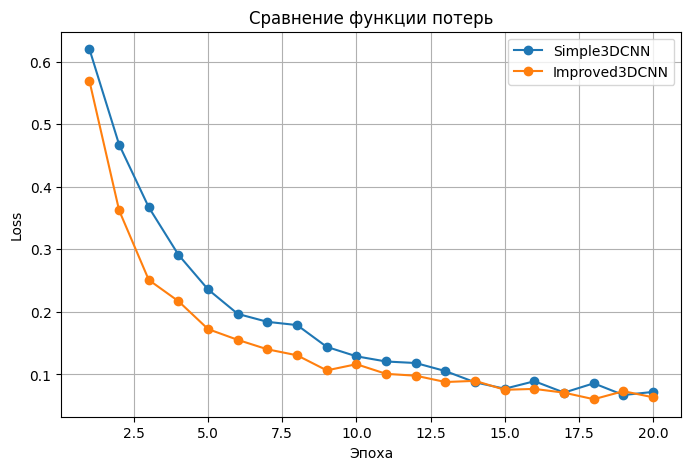

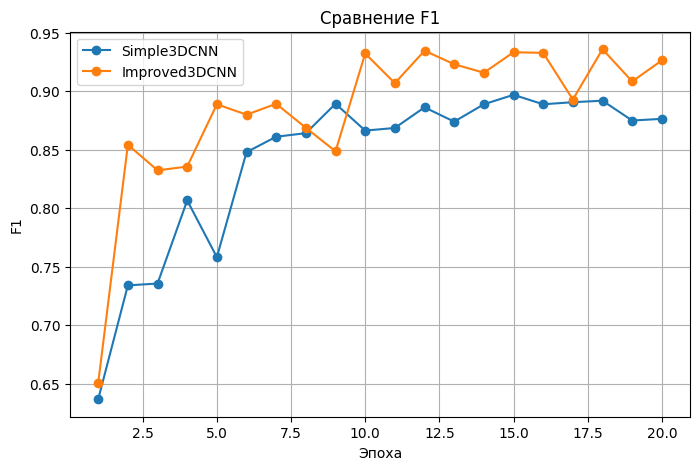

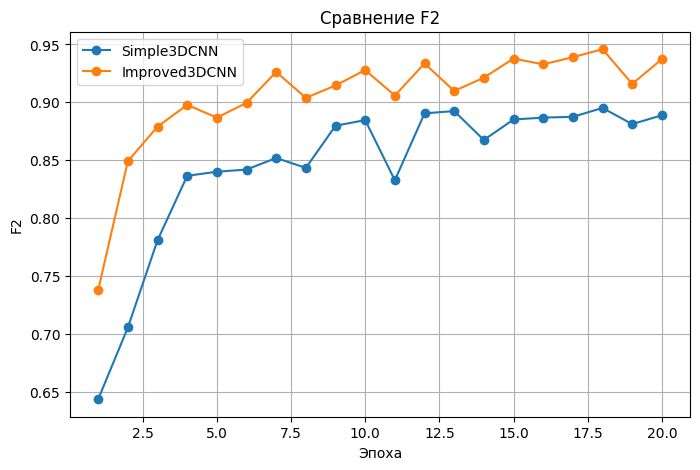

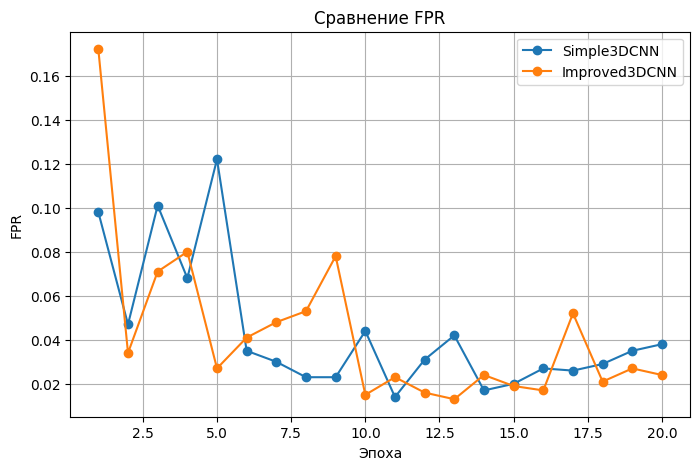

Исходная модель Simple3DCNN


,epoch,loss,f1,f2,fpr,tp,fp,fn,tn
0,1,0.620095,0.636893,0.643642,0.098,164,98,89,902
1,2,0.467510,0.734177,0.705596,0.047,174,47,79,953
2,3,0.367259,0.735714,0.780895,0.101,206,101,47,899
3,4,0.291280,0.806691,0.836546,0.068,217,68,36,932
4,5,0.235823,0.758278,0.840059,0.122,229,122,24,878
5,6,0.196770,0.848000,0.841938,0.035,212,35,41,965
6,7,0.184086,0.861167,0.851911,0.030,214,30,39,970
7,8,0.178890,0.864198,0.843373,0.023,210,23,43,977
8,9,0.144025,0.889336,0.879777,0.023,221,23,32,977
9,10,0.128954,0.866412,0.884645,0.044,227,44,26,956


Улучшенная модель Improved3DCNN


,epoch,loss,f1,f2,fpr,tp,fp,fn,tn
0,1,0.569136,0.650794,0.737941,0.172,205,172,48,828
1,2,0.362330,0.854291,0.849206,0.034,214,34,39,966
2,3,0.251082,0.832432,0.878995,0.071,231,71,22,929
3,4,0.217073,0.835664,0.897821,0.080,239,80,14,920
4,5,0.172447,0.888889,0.886778,0.027,224,27,29,973
5,6,0.155252,0.880000,0.899533,0.041,231,41,22,959
6,7,0.140127,0.889299,0.926211,0.048,241,48,12,952
7,8,0.130566,0.868762,0.903846,0.053,235,53,18,947
8,9,0.106466,0.848696,0.914543,0.078,244,78,9,922
9,10,0.116351,0.932271,0.927835,0.015,234,15,19,985


In [12]:

# График функции потерь для двух моделей

plt.figure(figsize=(8, 5))

plt.plot(
    simple_history["epoch"],
    simple_history["loss"],
    marker="o",
    label="Simple3DCNN"
)

plt.plot(
    improved_history["epoch"],
    improved_history["loss"],
    marker="o",
    label="Improved3DCNN"
)

plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Сравнение функции потерь")
plt.legend()
plt.grid()
plt.show()


# График F1 для двух моделей

plt.figure(figsize=(8, 5))

plt.plot(
    simple_history["epoch"],
    simple_history["f1"],
    marker="o",
    label="Simple3DCNN"
)

plt.plot(
    improved_history["epoch"],
    improved_history["f1"],
    marker="o",
    label="Improved3DCNN"
)

plt.xlabel("Эпоха")
plt.ylabel("F1")
plt.title("Сравнение F1")
plt.legend()
plt.grid()
plt.show()


# График F2 для двух моделей

plt.figure(figsize=(8, 5))

plt.plot(
    simple_history["epoch"],
    simple_history["f2"],
    marker="o",
    label="Simple3DCNN"
)

plt.plot(
    improved_history["epoch"],
    improved_history["f2"],
    marker="o",
    label="Improved3DCNN"
)

plt.xlabel("Эпоха")
plt.ylabel("F2")
plt.title("Сравнение F2")
plt.legend()
plt.grid()
plt.show()


# График FPR для двух моделей

plt.figure(figsize=(8, 5))

plt.plot(
    simple_history["epoch"],
    simple_history["fpr"],
    marker="o",
    label="Simple3DCNN"
)

plt.plot(
    improved_history["epoch"],
    improved_history["fpr"],
    marker="o",
    label="Improved3DCNN"
)

plt.xlabel("Эпоха")
plt.ylabel("FPR")
plt.title("Сравнение FPR")
plt.legend()
plt.grid()
plt.show()


# Итоговые значения по эпохам

print("Исходная модель Simple3DCNN")
display(simple_history)

print("Улучшенная модель Improved3DCNN")
display(improved_history)


## Этап 11. Постобработка предсказаний и подбор порога

Оптимальный порог выбирается по максимальному F2; при равном F2 предпочтение отдаётся меньшему FPR. (берется F2 так как она больше штрафует за FN, что критично для медицинского сервиса)


In [14]:


model = improved_model
trainer = improved_trainer
history = improved_history


all_true, all_probabilities = trainer.predict_proba()

threshold_results = []

for threshold in np.arange(0.1, 0.91, 0.05):
    predictions = (
        all_probabilities >= threshold
    ).astype(int)

    f1 = f1_score(
        all_true,
        predictions,
        zero_division=0
    )

    f2 = fbeta_score(
        all_true,
        predictions,
        beta=2,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        all_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0
    )

    threshold_results.append({
        "threshold": round(float(threshold), 2),
        "f1": f1,
        "f2": f2,
        "fpr": fpr,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn
    })


threshold_results = pd.DataFrame(
    threshold_results
)

best_result = (
    threshold_results
    .sort_values(
        ["f2", "fpr"],
        ascending=[False, True]
    )
    .iloc[0]
)

threshold_results

,threshold,f1,f2,fpr,tp,fp,fn,tn
0,0.10,0.867725,0.927602,0.068,246,68,7,932
1,0.15,0.895795,0.937979,0.049,245,49,8,951
2,0.20,0.909091,0.943760,0.041,245,41,8,959
3,0.25,0.919325,0.948142,0.035,245,35,8,965
4,0.30,0.916981,0.942591,0.034,243,34,10,966
5,0.35,0.920152,0.941634,0.031,242,31,11,969
6,0.40,0.917782,0.936037,0.030,240,30,13,970
7,0.45,0.921002,0.935055,0.027,239,27,14,973
8,0.50,0.926357,0.937255,0.024,239,24,14,976
9,0.55,0.928155,0.937991,0.023,239,23,14,977


## Этап 12. Итоговая оценка качества

Оптимальный порог: 0.25
F1: 0.9193
F2: 0.9481
FPR: 0.035
TP: 245 FP: 35 FN: 8 TN: 965


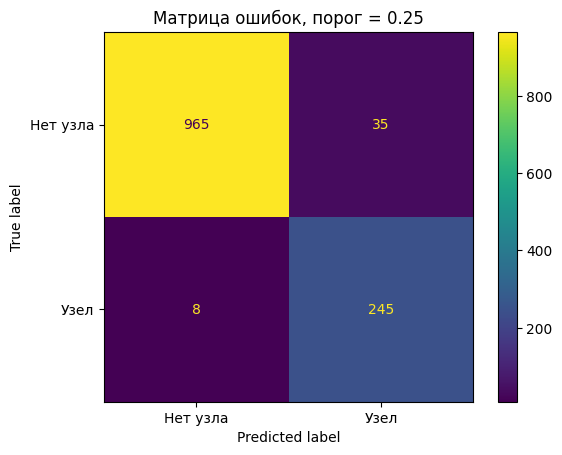

In [15]:

best_threshold = best_result["threshold"]
final_predictions = (all_probabilities >= best_threshold).astype(int)

print("Оптимальный порог:", best_threshold)
print("F1:", round(best_result["f1"], 4))
print("F2:", round(best_result["f2"], 4))
print("FPR:", round(best_result["fpr"], 4))
print(
    "TP:", int(best_result["tp"]),
    "FP:", int(best_result["fp"]),
    "FN:", int(best_result["fn"]),
    "TN:", int(best_result["tn"])
)

ConfusionMatrixDisplay.from_predictions(
    all_true,
    final_predictions,
    display_labels=["Нет узла", "Узел"],
    values_format="d"
)
plt.title(f"Матрица ошибок, порог = {best_threshold:.2f}")
plt.show()


## Этап 13. Выводы

Сложность обучения модели в моем случае - это технические ограничения. Размер дата сета огромный и Кегеля надолго не хватает, приходится обучать на своем железе. Вроде как учел все замечания, сейчас должно быть лучше. Спасибо за терпение!

В принципе обе модели достигают целевых значений основных метрик, указанных в предыдущих уроках: F1: выше 0,9; F2: выше 0,9; FPR: не выше 0,25. 